In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import IsolationForest
from xgboost import XGBRegressor

import holidays
import requests
import unicodedata

df3 = pd.read_csv("datos_final.csv")
df4 = pd.read_csv("final_2024.csv")
df5 = pd.read_csv("final_2025.csv")

In [15]:
def categorizar(diag):
    d = str(diag).upper()

    if any(x in d for x in [
        "TOS", "GRIP", "BRONQUITIS", "RESP", "GARGANTA",
        "NEUMONIA", "CONGESTION", "RAO", "DISNEA", "DIFICULTAD RESPIRATORIA",
        "AFONIA", "ANGINAS", "OTITIS", "CATARRO", "BRONCOESPASMO", "EPOC",
        "FALTA DE AIRE", "CRISIS ASMATICA", "FARINGITIS", "DERRAME PLEURAL",
        "NEUMOPATIA", "SINUSITIS", "BRONCOASPIRACION"
    ]):
        return "RESPIRATORIO"

    if any(x in d for x in [
        "HTA", "HIPERTENSION", "PRESION", "PECHO",
        "PRECORDIAL", "TAQUICARDIA", "HIPOTENSION",
        "PALPITACIONES", "SINCOPE", "DESMAYO",
        "CRISIS HIPERTENSIVA", "ACV", "ICC", "INS CARDIACA",
        "DOLOR TORAXICO", "A.C.V", "INSUFICIENCIA CARDIACA",
        "H.T.A", "BRADICARDIA", "INSUF CARDIACA", "HIPERTENSA",
        "FIBRILACION AURICULAR", "ISUF CARDIACA"
    ]):
        return "CARDIOVASCULAR"

    if any(x in d for x in [
        "TRAUMA", "CAIDA", "ACCIDENTE", "TEC",
        "HERIDA", "MORDEDURA", "TX", "LESION",
        "CHOQUE", "MOTO", "QUEMADURA", "DESGARRO",
        "GOLPE", "CORTE", "FX DE MUÑECA", "FX DE DEDO",
        "TIRON EN MS"
    ]):
        return "TRAUMA"

    if any(x in d for x in [
        "ABD", "VOMIT", "DIARREA", "NAUSEA",
        "CONSTIPACION", "COLICO", "GASTRO", "GASTROENTERITIS",
        "DOLOR BAJO VIENTRE", "HEMORROIDES", "HDB", "PROCTORRAGIA",
        "HERNIA INGUINAL", "DOLOR INGUINAL", "DOLOR CORPORAL",
        "ORINA CON SANGRE", "HEMATURIA", "INSUF URINARIA",
        "DOLOR EN INGLE", "DOLOR DE COLUMNA",
        "HEMORRAGIA DIGESTIVA BAJA", "HEMORRAGIA DIGESTIVA",
        "OBSTRUCCION INTESTINAL", "MELENA", "HDA", "METRORRAGIA",
        "BOLO FECAL", "CONSTIPADA", "PROCTORRAGEA",
        "SANGRADO RECTAL", "SME COLEDOCIANO"
    ]):
        return "GASTROINTESTINAL"

    if any(x in d for x in [
        "FIEBRE", "INFECCION", "ITU",
        "DESHIDRATACION", "CELULITIS", "SIND FEBRIL",
        "FORUNCULO", "HERPES", "CONJUNTIVITIS",
        "DERMATITIS", "ASCITIS", "SINDROME FEBRIL",
        "DEDO INFECTADO", "GANGLIOS INFLAMADOS", "ESTADO FEBRIL",
        "SEPSIS", "INFECC URINARIA"
    ]):
        return "INFECCIOSO"

    if any(x in d for x in [
        "ESPALDA", "LUMBAR", "CINTURA", "COSTAL",
        "CERVICAL", "HOMBRO", "CADERA",
        "CIATICO", "CIATALGIA", "DOLOR MS", "DOLOR MI",
        "RODILLA", "TOBILLO", "M I", "MI", "PIERNA",
        "MUSCULAR", "PIE", "DOLOR DE CUELLO", "CONTRACTURA",
        "DOLOR EN MS", "DOLOR TESTICULAR", "CIATICA",
        "DOLOR AGUDO", "DOLOR DE CUERPO", "DOLOR M SUPERIOR",
        "TENDINITIS", "DOLOR DE MUÑECA", "DOLOR BRAZO IZQUIERDO",
        "DOLOR COLUMNA", "TVP", "DOLOR FACIAL",
        "LUMBALGIA", "TORTICOLIS",
        "HERNIA", "HERNIA UMBILICAL"
    ]):
        return "MUSCULOESQUELETICO"

    if any(x in d for x in [
        "MAREO", "CEFALEA", "CABEZA", "MIGRAÑA",
        "VERTIGO", "SINCOPE", "DESMAYO",
        "DEBILIDAD", "TEMBLORES", "DETERIORO SENSORIO",
        "AGITACION", "PARALISIS FACIAL",
        "ATAQUE DE PANICO", "CONVULSIONES", "MEG",
        "ANSIEDAD", "CRISIS NERVIOSA",
        "PERDIDA EN TIEMPO Y ESPACIO",
        "POST CONVULSIVO"
    ]):
        return "NEURO"

    if any(x in d for x in [
        "ALERG", "PIEL", "REACCION", "PICADURA",
        "ZARPULLIDO", "MORDIDA DE CAN", "SARPULLIDO",
        "TIENE LA CARA INFLAMADA",
        "MORDIDA DE PERRO", "MORDIDA DE GATO", "EDEMA FACIAL",
        "INFLAMACION EN LA CARA"
    ]):
        return "ALERGIA"

    if any(x in d for x in [
        "HEMATURIA", "ANURIA", "ORINAR", "SONDA", "RENAL",
        "RETENCION DE ORINA", "DOLOR DE RIÑONES", "DISURIA",
        "NO PUEDE HACER PIS", "RETENCION AGUDA DE ORINA",
        "GLOBO VESICAL", "ORINA C SANGRE"
    ]):
        return "UROLOGICO"

    if any(x in d for x in [
        "OIDO", "OTORRINO", "OTITIS", "EPISTAXIS",
        "HEMORRAGIA NASAL", "EPITAXIS", "DISFONIA",
        "DOLOR EN CUELLO", "R A O",
        "SANGRADO NASAL"
    ]):
        return "OTORRINO"

    if any(x in d for x in [
        "MUELA", "MUELAS", "ODONTO", "DENTAL",
        "ODONTALGIA", "MOLESTIA EN OJO", "FLEMON",
        "DOLOR BUCAL", "VISTA IRRITADA",
        "LLAGAS EN LA BOCA",
        "CUERPO EXTRAÑO EN EL OJO",
        "CUERPO EXTRAÑO EN ESOFAGO"
    ]):
        return "DENTAL"

    if any(x in d for x in [
        "ANEMIA", "HIPERGLUCEMIA", "DESCOMPUESTA",
        "METABOLICO", "PIE DIABETICO", "DESCOMPENSADA",
        "MAL ESTADO GRAL", "MAL ESTADO GENERAL",
        "DESCOMPUESTO", "DESCOMPENSADO",
        "RESULTADOS", "DESCOMPOSTURA"
    ]):
        return "METABOLICO"

    if "PEDIATRIA" in d:
        return "PEDIATRIA"

    if any(x in d for x in [
        "CONTROL DE CIRUGIA",
        "PARA PONCE",
        "CONSULTA PONCE",
        "PCTE PONCE",
        "PACIENTE PONCE",
        "CONTROL PONCE",
        "ORDEN DE INTERNACION",
        "RECONSULTA",
        "AMBULANCIA"
    ]):
        return "CONSULTAS"

    return "OTROS"

In [17]:
def preparar_df(df):

    df = df.copy()
    df.drop(columns=['Unnamed: 3'], inplace=True)
    df.drop(columns=["segundo"], inplace=True, errors="ignore")
    df = df.rename(columns={"PACIENTE": "GENERO"})

    df["hora"] = pd.to_numeric(df["hora"], errors="coerce")

    df["fecha_hora"] = pd.to_datetime(
        dict(
            year=df["año"],
            month=df["mes"],
            day=df["dia"],
            hour=df["hora"],
            minute=df["minuto"]
        ),
        errors="coerce"
    )

    df = df.dropna(subset=["fecha_hora"])

    return df

df_2023 = preparar_df(df3)
df_2024 = preparar_df(df4)
df_2025 = preparar_df(df5)

df = pd.concat(
    [df_2023, df_2024, df_2025],
    ignore_index=True
)

df = df.sort_values("fecha_hora")
df["fecha_hora"] = df["fecha_hora"].dt.floor("h")

df = df.dropna(subset=["fecha_hora"])

df["dia_semana"] = df["fecha_hora"].dt.dayofweek
df["fin_semana"] = (df["dia_semana"] >= 5).astype(int)

cols_drop = [
    "dia",
    "mes",
    "año",
    "hora",
    "minuto"
]

df.drop(columns=cols_drop, inplace=True)

df["ATENCIÓN"] = df["ATENCIÓN"].replace({
    "ATENDIDA": "ATENDIDO",
    "ATENDIDO": "ATENDIDO",
    "SE RETIRO": "RETIRO"
})

df["DIAGNOSTICO"] = df["DIAGNOSTICO"].apply(categorizar)

df.info()

<class 'pandas.DataFrame'>
Index: 52502 entries, 18365 to 34601
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   GENERO       52502 non-null  str           
 1   OBRA SOCIAL  52502 non-null  str           
 2   DIAGNOSTICO  52502 non-null  str           
 3   ATENCIÓN     52502 non-null  str           
 4   MEDICO       52502 non-null  str           
 5   ESTACION     52502 non-null  str           
 6   PERIODO_DIA  52502 non-null  str           
 7   fecha_hora   52502 non-null  datetime64[us]
 8   dia_semana   52502 non-null  int32         
 9   fin_semana   52502 non-null  int64         
dtypes: datetime64[us](1), int32(1), int64(1), str(7)
memory usage: 7.9 MB


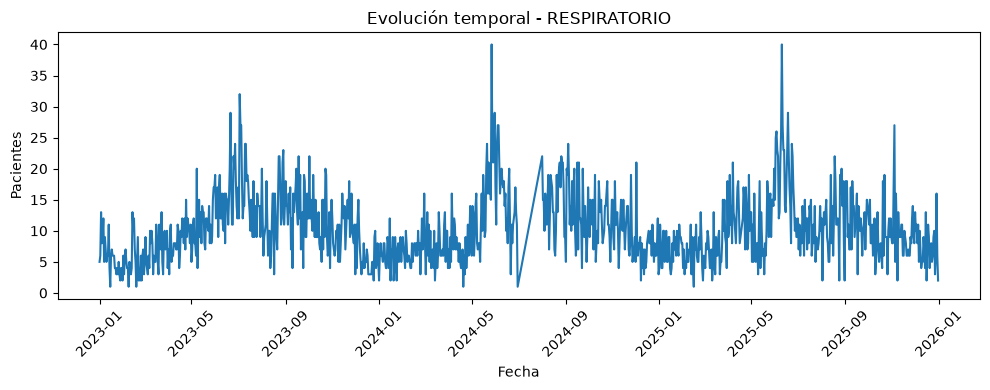

In [18]:
df = df.copy()

df["DIAGNOSTICO"] = df["DIAGNOSTICO"].str.strip()
df["fecha"] = df["fecha_hora"].dt.floor("D")

resp_ts = (
    df[df["DIAGNOSTICO"] == "RESPIRATORIO"]
    .groupby("fecha")
    .size()
    .reset_index(name="pacientes")
)

plt.figure(figsize=(10, 4))
plt.plot(resp_ts["fecha"], resp_ts["pacientes"])

plt.title("Evolución temporal - RESPIRATORIO")
plt.xlabel("Fecha")
plt.ylabel("Pacientes")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
diag_ts["rolling_7d"] = (
    diag_ts.groupby("DIAGNOSTICO")["pacientes"]
    .transform(lambda x: x.rolling(7).mean())
)
fig = px.line(
    diag_ts,
    x="fecha",
    y="rolling_7d",
    color="DIAGNOSTICO",
    title="Tendencia suavizada (7 días) por diagnóstico"
)

fig.show()

In [28]:
med_ts = (
    df.groupby(["fecha", "MEDICO"])
    .size()
    .reset_index(name="pacientes")
)

top_med = (
    df["MEDICO"]
    .value_counts()
    .head(5)
    .index
)

med_ts = med_ts[med_ts["MEDICO"].isin(top_med)]

fig = px.line(
    med_ts,
    x="fecha",
    y="pacientes",
    color="MEDICO",
    title="Evolución temporal por médico (Top 5)"
)

fig.show()

In [17]:
df["fecha"] = df["fecha_hora"].dt.date

pacientes_dia = df.groupby("fecha").size().reset_index(name="pacientes")

pacientes_dia.head()

,fecha,pacientes
0,2023-01-01,26
1,2023-01-02,56
2,2023-01-03,51
3,2023-01-04,50
4,2023-01-05,51


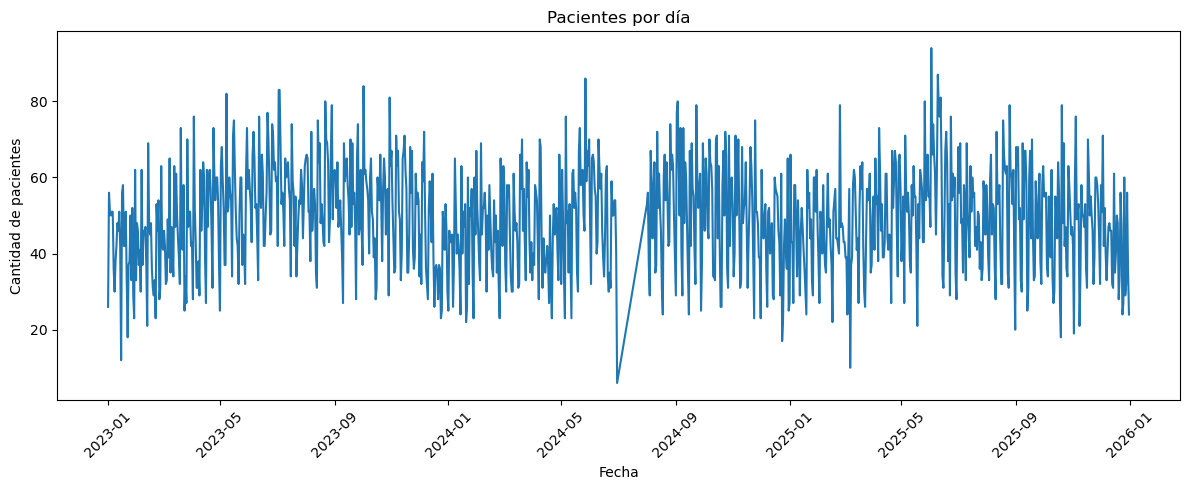

In [18]:

plt.figure(figsize=(12,5))
plt.plot(pacientes_dia["fecha"], pacientes_dia["pacientes"])
plt.title("Pacientes por día")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de pacientes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
pacientes_dia.sort_values("pacientes", ascending=False).head(10)

,fecha,pacientes,media_7d
852,2025-06-02,94,61.428571
859,2025-06-09,87,65.714286
512,2024-05-27,86,62.285714
274,2023-10-02,84,56.428571
184,2023-07-04,83,64.714286
183,2023-07-03,83,63.000000
127,2023-05-08,82,56.857143
302,2023-10-30,81,56.142857
862,2025-06-12,81,69.857143
845,2025-05-26,80,55.571429


In [19]:
df_model = (
    df.set_index("fecha_hora")
      .resample("H")
      .size()
      .reset_index(name="demanda")
)

df_model["hora"] = df_model["fecha_hora"].dt.hour
df_model["dia_semana"] = df_model["fecha_hora"].dt.dayofweek
df_model["mes"] = df_model["fecha_hora"].dt.month

df_model["hora_sin"] = np.sin(2*np.pi*df_model["hora"]/24)
df_model["hora_cos"] = np.cos(2*np.pi*df_model["hora"]/24)

df_model["dow_sin"] = np.sin(2*np.pi*df_model["dia_semana"]/7)
df_model["dow_cos"] = np.cos(2*np.pi*df_model["dia_semana"]/7)

df_model["mes_sin"] = np.sin(2*np.pi*df_model["mes"]/12)
df_model["mes_cos"] = np.cos(2*np.pi*df_model["mes"]/12)

df_model = df_model.sort_values("fecha_hora")

df_model["lag_1"] = df_model["demanda"].shift(1)
df_model["lag_24"] = df_model["demanda"].shift(24)
df_model["lag_168"] = df_model["demanda"].shift(168)

df_model["roll_24"] = df_model["demanda"].shift(1).rolling(24).mean()

df_model["roll_168"] = (
    df_model["demanda"]
    .shift(1)
    .rolling(168)
    .mean()
)

ar_holidays = holidays.Argentina()

df_model["feriado"] = df_model["fecha_hora"].dt.date.isin(ar_holidays).astype(int)

feriados = set(ar_holidays.keys())

df_model["vispera_feriado"] = (
    (df_model["fecha_hora"].dt.date + pd.Timedelta(days=1))
    .isin(feriados)
    .astype(int)
)

df_model = df_model.dropna()


/tmp/ipykernel_44841/3984502993.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("H")


In [6]:
fecha_inicio = "2023-01-01"
fecha_fin = "2025-12-31"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=-38.7196"
    "&longitude=-62.2724"
    f"&start_date={fecha_inicio}"
    f"&end_date={fecha_fin}"
    "&hourly=temperature_2m,relative_humidity_2m,precipitation"
)

response = requests.get(url)
data = response.json()

if "hourly" not in data:
    raise ValueError("API error o respuesta inválida")

clima = pd.DataFrame({
    "fecha_hora": data["hourly"]["time"],
    "temperatura": data["hourly"]["temperature_2m"],
    "humedad": data["hourly"]["relative_humidity_2m"],
    "lluvia": data["hourly"]["precipitation"]
})

clima["fecha_hora"] = pd.to_datetime(clima["fecha_hora"])
clima["fecha_hora"] = clima["fecha_hora"].dt.floor("H")

clima = clima.drop_duplicates(subset=["fecha_hora"])
clima = clima.sort_values("fecha_hora")

df_model["fecha_hora"] = df_model["fecha_hora"].dt.floor("H")

df_model = df_model.merge(
    clima,
    on="fecha_hora",
    how="left"
)

df_model = df_model.dropna()
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26131 entries, 0 to 26130
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha_hora       26131 non-null  datetime64[ns]
 1   demanda          26131 non-null  int64         
 2   hora             26131 non-null  int32         
 3   dia_semana       26131 non-null  int32         
 4   mes              26131 non-null  int32         
 5   hora_sin         26131 non-null  float64       
 6   hora_cos         26131 non-null  float64       
 7   dow_sin          26131 non-null  float64       
 8   dow_cos          26131 non-null  float64       
 9   mes_sin          26131 non-null  float64       
 10  mes_cos          26131 non-null  float64       
 11  lag_1            26131 non-null  float64       
 12  lag_24           26131 non-null  float64       
 13  lag_168          26131 non-null  float64       
 14  roll_24          26131 non-null  float

/tmp/ipykernel_44841/409844278.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  clima["fecha_hora"] = clima["fecha_hora"].dt.floor("H")
/tmp/ipykernel_44841/409844278.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_model["fecha_hora"] = df_model["fecha_hora"].dt.floor("H")


In [7]:
#df_model.to_csv("df_model.csv", index=False)

In [8]:
features = [
    "hora_sin","hora_cos",
    "dow_sin","dow_cos",
    "mes_sin","mes_cos",
    "lag_1","lag_24","lag_168",
    "roll_24",
    "feriado","vispera_feriado",
    "temperatura","humedad","lluvia"
]

df_model = df_model.sort_values("fecha_hora").dropna()

train = df_model[df_model["fecha_hora"] < "2025-01-01"]
test = df_model[df_model["fecha_hora"] >= "2025-01-01"]

X_train = train[features]
y_train = train["demanda"]

X_test = test[features]
y_test = test["demanda"]

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)

print("MAE modelo:", mae)

MAE modelo: 1.1115364561707708


In [9]:
#import joblib

#joblib.dump(model, "xgb_demanda.pkl")

['xgb_demanda.pkl']

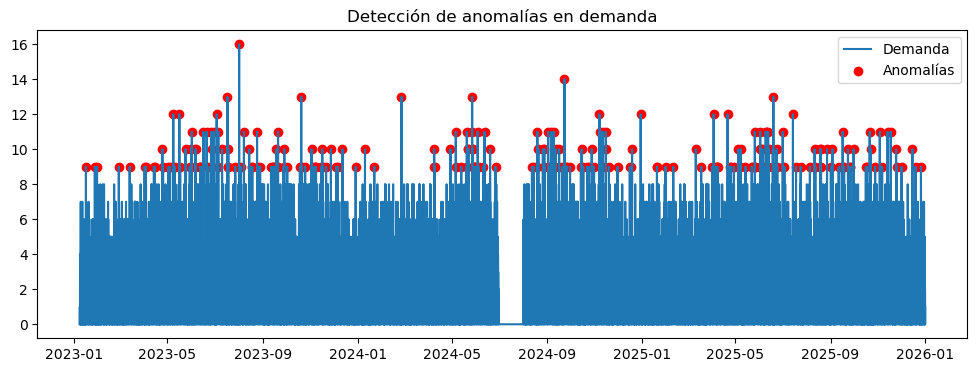

In [10]:
anom_model = IsolationForest(contamination=0.01, random_state=42)

df_model["anomaly"] = anom_model.fit_predict(df_model[["demanda"]])

df_model["anomaly_flag"] = (df_model["anomaly"] == -1).astype(int)

plt.figure(figsize=(12,4))
plt.plot(df_model["fecha_hora"], df_model["demanda"], label="Demanda")
plt.scatter(
    df_model[df_model["anomaly_flag"] == 1]["fecha_hora"],
    df_model[df_model["anomaly_flag"] == 1]["demanda"],
    color="red",
    label="Anomalías"
)
plt.legend()
plt.title("Detección de anomalías en demanda")
plt.show()

In [11]:
horizons = [1, 24, 72]
results = {}

for h in horizons:
    df_model[f"target_t+{h}"] = df_model["demanda"].shift(-h)

    features_h = features  # reutilizas las tuyas

    temp = df_model.dropna()

    split = int(len(temp)*0.8)

    X_train = temp[features_h].iloc[:split]
    y_train = temp[f"target_t+{h}"].iloc[:split]

    X_test = temp[features_h].iloc[split:]
    y_test = temp[f"target_t+{h}"].iloc[split:]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    results[h] = mae

results

{1: np.float64(1.1035389689841848),
 24: np.float64(1.1153803943664946),
 72: np.float64(1.1085638334081742)}

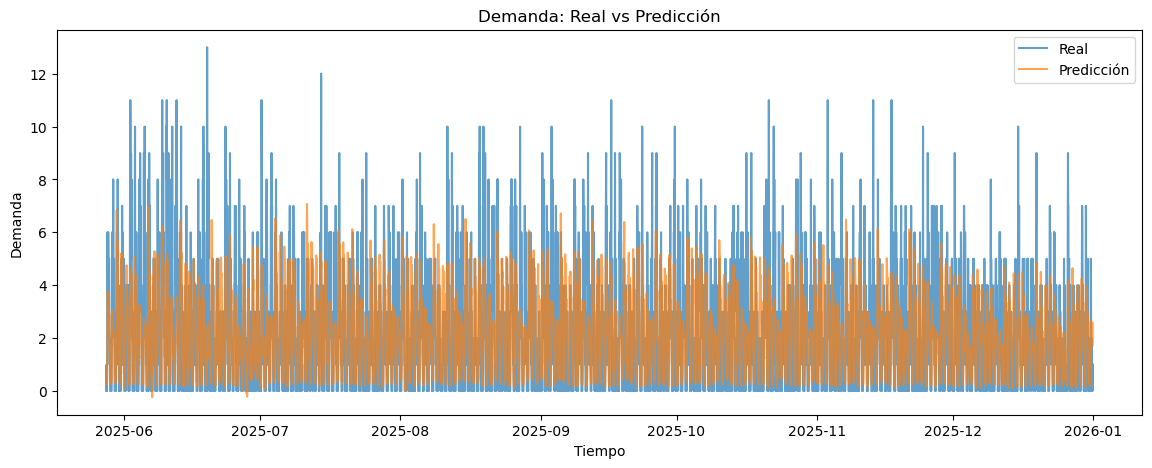

In [12]:
test = df_model.iloc[int(len(df_model)*0.8):].copy()

test = test.dropna(subset=features)

X_test = test[features]
y_test = test["demanda"]

preds = model.predict(X_test)

plt.figure(figsize=(14,5))

plt.plot(test["fecha_hora"], y_test.values, label="Real", alpha=0.7)
plt.plot(test["fecha_hora"], preds, label="Predicción", alpha=0.7)

plt.title("Demanda: Real vs Predicción")
plt.xlabel("Tiempo")
plt.ylabel("Demanda")
plt.legend()
plt.show()

In [13]:
horizon = 24 * 7  # 7 días

errors = []

for i in range(3):
    train_end = len(df_model) - (horizon * (i+1))
    test_end = len(df_model) - (horizon * i)

    train = df_model.iloc[:train_end]
    test = df_model.iloc[train_end:test_end]

    model.fit(train[features], train["demanda"])
    preds = model.predict(test[features])

    errors.append(mean_absolute_error(test["demanda"], preds))

print(errors)
print("MAE promedio:", sum(errors)/len(errors))

[np.float64(1.121335866461907), np.float64(0.9794865679882822), np.float64(1.0549735226446675)]
MAE promedio: 1.0519319856982856
